# Rossmann Store Sales Prediction

## Main Objective

### The objective of this project is to analyze Rossmann’s historical store data and build a machine learning model that can predict daily sales for each store.

### Step 1: Data Loading & Initial Observations

In [174]:
import pandas as pd

# Load datasets
train = pd.read_csv("train.csv")
store = pd.read_csv("store.csv")
test = pd.read_csv("test.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_19768\749509136.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


### Display first few rows

In [175]:
print("Train Data:")
print(train.head())

Train Data:
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  


In [176]:
print("\nStore Data:")
print(store.head())


Store Data:
   Store StoreType Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0      1         c          a               1270.0                        9.0   
1      2         a          a                570.0                       11.0   
2      3         a          a              14130.0                       12.0   
3      4         c          c                620.0                        9.0   
4      5         a          a              29910.0                        4.0   

   CompetitionOpenSinceYear  Promo2  Promo2SinceWeek  Promo2SinceYear  \
0                    2008.0       0              NaN              NaN   
1                    2007.0       1             13.0           2010.0   
2                    2006.0       1             14.0           2011.0   
3                    2009.0       0              NaN              NaN   
4                    2015.0       0              NaN              NaN   

     PromoInterval  
0              NaN  
1  Jan,Apr,Jul,Oct 

In [177]:
print("\nTest Data:")
print(test.head())


Test Data:
   Id  Store  DayOfWeek        Date  Open  Promo StateHoliday  SchoolHoliday
0   1      1          4  2015-09-17   1.0      1            0              0
1   2      3          4  2015-09-17   1.0      1            0              0
2   3      7          4  2015-09-17   1.0      1            0              0
3   4      8          4  2015-09-17   1.0      1            0              0
4   5      9          4  2015-09-17   1.0      1            0              0


In [178]:

# Check data types and info
print("\nTrain Info:")
print(train.info())


Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB
None


In [179]:
print("\nStore Info:")
print(store.info())


Store Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB
None


In [180]:
print("\nTest Info:")
print(test.info())


Test Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek      41088 non-null  int64  
 3   Date           41088 non-null  object 
 4   Open           41077 non-null  float64
 5   Promo          41088 non-null  int64  
 6   StateHoliday   41088 non-null  object 
 7   SchoolHoliday  41088 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 2.5+ MB
None


### Step 2: Data Cleaning & Preparation

### Step 2.1: Merge datasets

In [181]:
# Merge train and store data on 'Store' because store info is in a separate file
data = pd.merge(train, store, on="Store", how="left")

print(data.head())

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                   

In [182]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

### Step 2.2: Remove closed stores

In [183]:
# Rows where the store was closed (Open = 0) were removed, 
# as they do not contribute meaningful information for predicting sales.
data = data[data["Open"] == 1]

In [184]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844392 non-null  int64  
 1   DayOfWeek                  844392 non-null  int64  
 2   Date                       844392 non-null  object 
 3   Sales                      844392 non-null  int64  
 4   Customers                  844392 non-null  int64  
 5   Open                       844392 non-null  int64  
 6   Promo                      844392 non-null  int64  
 7   StateHoliday               844392 non-null  object 
 8   SchoolHoliday              844392 non-null  int64  
 9   StoreType                  844392 non-null  object 
 10  Assortment                 844392 non-null  object 
 11  CompetitionDistance        842206 non-null  float64
 12  CompetitionOpenSinceMonth  575773 non-null  float64
 13  CompetitionOpenSinceYear   575773

### Step 2.3: Handle missing values

In [185]:
# Check missing values
print(data.isnull().sum())

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2                            0
Promo2SinceWeek              423307
Promo2SinceYear              423307
PromoInterval                423307
dtype: int64


In [186]:
# Fill missing CompetitionDistance with median
data["CompetitionDistance"] = data["CompetitionDistance"].fillna(data["CompetitionDistance"].median())

data["Promo2"] = data["Promo2"].fillna(0)
data["Promo2SinceWeek"] = data["Promo2SinceWeek"].fillna(0)
data["Promo2SinceYear"] = data["Promo2SinceYear"].fillna(0)
data["PromoInterval"] = data["PromoInterval"].fillna("None")

## Step 3: Exploratory Data Analysis (EDA)

### Objective: The goal of EDA is to explore how sales behave and which factors may influence them.

### Step 3.1: Summary statistics of Sales

In [187]:
print(data["Sales"].describe())

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


#### From .describe()
#### Mean ≈ 5773
#### Median ≈ 5744
#### Mean ≈ Median → data is somewhat balanced in center

#### However I can see,
#### Max = 41,551 😳
#### 75% = 7,856

#### Huge gap → indicates extreme high values

### Step 3.2: Check sales distribution visually

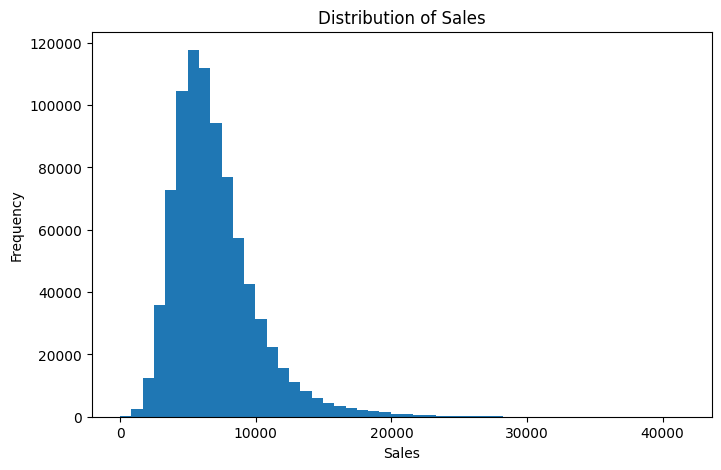

In [188]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(data["Sales"], bins=50)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# A histogram was used to visualize the distribution of daily sales. 
# This helps determine whether the target variable is symmetric, skewed, or affected by extreme values.

### From Histogram: Data is right-skewed (positively skewed)
### 1. Most sales are between 0 – 10,000
### 2. Few stores have very high sales (long tail)

### Step 3.3: Check whether outliers may exist

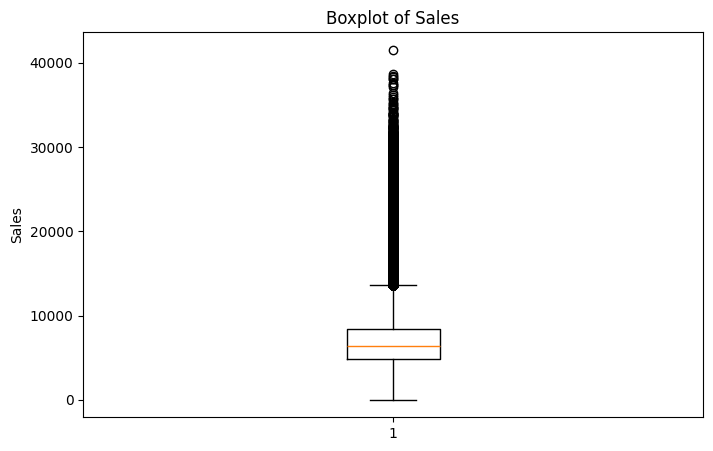

In [189]:
plt.figure(figsize=(8, 5))
plt.boxplot(data["Sales"])
plt.title("Boxplot of Sales")
plt.ylabel("Sales")
plt.show()

##### From Boxplot: Massive number of outliers
##### 1. Many points above upper whisker
##### 2. Sales going up to 40k+

### Step 3.4: Impact of Promotions on Sales

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


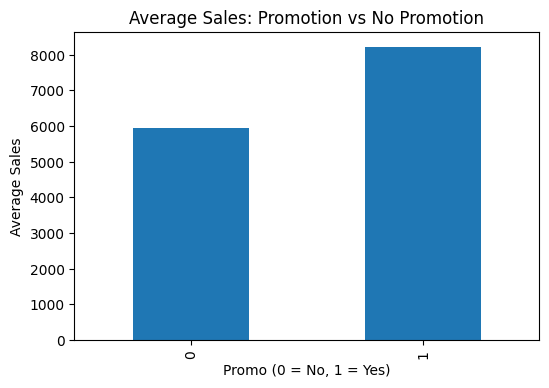

In [190]:
import matplotlib.pyplot as plt

# Average sales with and without promotion
promo_sales = data.groupby("Promo")["Sales"].mean()

print(promo_sales)

# Visualization
plt.figure(figsize=(6, 4))
promo_sales.plot(kind="bar")
plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promo (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")
plt.show()

### Step 3.5: Sales vs Day of Week

DayOfWeek
1    8216.073074
2    7088.113656
3    6728.122978
4    6767.310159
5    7072.677012
6    5874.840238
7    8224.723908
Name: Sales, dtype: float64


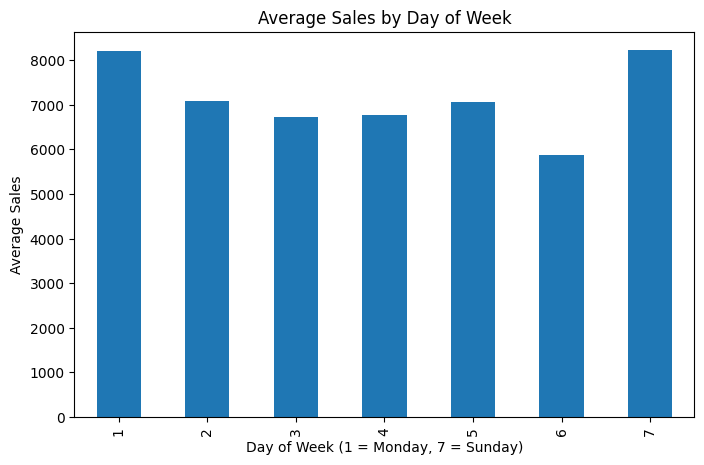

In [191]:
# Average sales by day of week
day_sales = data.groupby("DayOfWeek")["Sales"].mean()

print(day_sales)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
day_sales.plot(kind="bar")
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week (1 = Monday, 7 = Sunday)")
plt.ylabel("Average Sales")
plt.show()

### Step 3.6: Sales vs Store Type

StoreType
a     6925.167661
b    10231.407505
c     6932.512755
d     6822.141881
Name: Sales, dtype: float64


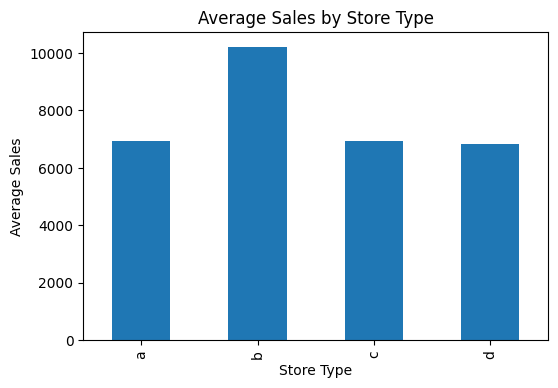

In [192]:
# Average sales by store type
store_sales = data.groupby("StoreType")["Sales"].mean()

print(store_sales)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
store_sales.plot(kind="bar")
plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.show()

### Step 3.7: Sales vs Customers

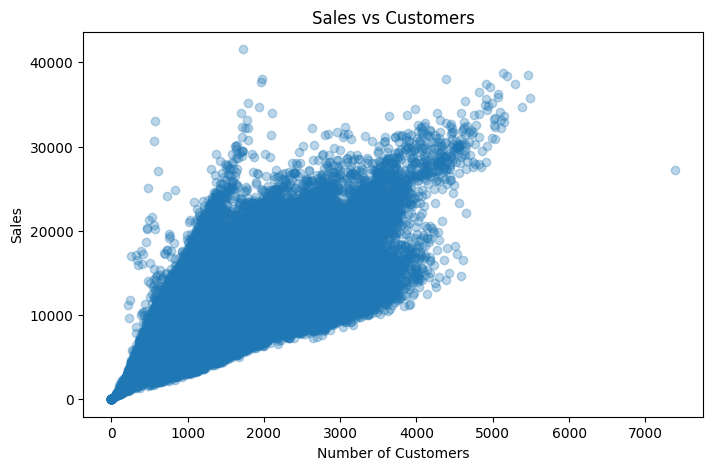

In [193]:
# Scatter plot: Customers vs Sales
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(data["Customers"], data["Sales"], alpha=0.3)
plt.title("Sales vs Customers")
plt.xlabel("Number of Customers")
plt.ylabel("Sales")
plt.show()

### Step 3.8: Sales vs Month (Seasonality)

In [194]:
data["Date"] = pd.to_datetime(data["Date"])
data["Month"] = data["Date"].dt.month

Month
1     6563.690444
2     6589.165535
3     6976.412026
4     7046.228420
5     7106.453154
6     7000.978190
7     6952.682125
8     6648.984654
9     6546.343035
10    6602.843354
11    7188.554250
12    8608.956661
Name: Sales, dtype: float64


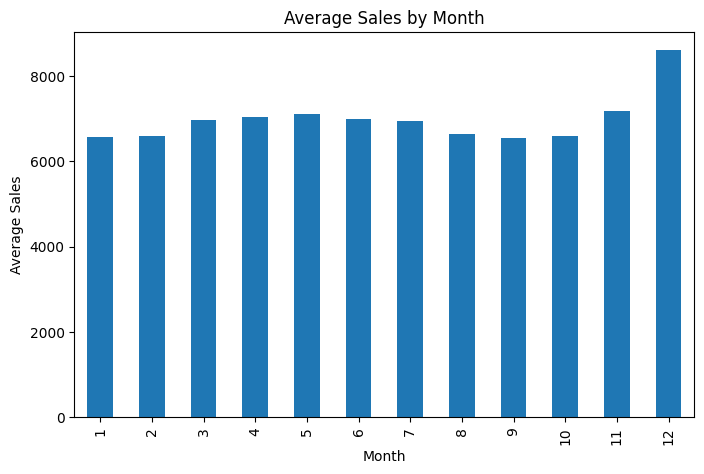

In [195]:
# Average sales by month
month_sales = data.groupby("Month")["Sales"].mean()

print(month_sales)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
month_sales.plot(kind="bar")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

### Step 4: Feature Engineering

In [196]:
# Ensure Date is datetime
data["Date"] = pd.to_datetime(data["Date"])

# DATE FEATURES
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day

# HANDLE MISSING VALUES (competition columns)
data["CompetitionOpenSinceMonth"] = data["CompetitionOpenSinceMonth"].fillna(0)
data["CompetitionOpenSinceYear"] = data["CompetitionOpenSinceYear"].fillna(0)

# ENCODE CATEGORICAL VARIABLES
data["StoreType"] = data["StoreType"].astype("category").cat.codes
data["Assortment"] = data["Assortment"].astype("category").cat.codes
data["StateHoliday"] = data["StateHoliday"].astype("category").cat.codes
data["PromoInterval"] = data["PromoInterval"].astype("category").cat.codes

# DROP DATE COLUMN
data = data.drop("Date", axis=1)

# FINAL CHECK
print(data.info())


<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844392 non-null  int64  
 1   DayOfWeek                  844392 non-null  int64  
 2   Sales                      844392 non-null  int64  
 3   Customers                  844392 non-null  int64  
 4   Open                       844392 non-null  int64  
 5   Promo                      844392 non-null  int64  
 6   StateHoliday               844392 non-null  int8   
 7   SchoolHoliday              844392 non-null  int64  
 8   StoreType                  844392 non-null  int8   
 9   Assortment                 844392 non-null  int8   
 10  CompetitionDistance        844392 non-null  float64
 11  CompetitionOpenSinceMonth  844392 non-null  float64
 12  CompetitionOpenSinceYear   844392 non-null  float64
 13  Promo2                     844392

In [197]:
print(data.head())

   Store  DayOfWeek  Sales  Customers  Open  Promo  StateHoliday  \
0      1          5   5263        555     1      1             1   
1      2          5   6064        625     1      1             1   
2      3          5   8314        821     1      1             1   
3      4          5  13995       1498     1      1             1   
4      5          5   4822        559     1      1             1   

   SchoolHoliday  StoreType  Assortment  CompetitionDistance  \
0              1          2           0               1270.0   
1              1          0           0                570.0   
2              1          0           0              14130.0   
3              1          2           2                620.0   
4              1          0           0              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                       11.0                    2007.0       1   
2       

In [198]:
# dropping customers to avoid data leakage
data = data.drop("Customers", axis=1)

### Step 5: Train-Test Split + First Model

#### Step 5.1: Define Features & Target

In [199]:
# Target variable
y = data["Sales"]

# Features (everything except Sales)
X = data.drop("Sales", axis=1)

#### Step 5.2: Train-Test Split

In [200]:
# Since this is time-based data, we do NOT shuffle randomly.
from sklearn.model_selection import train_test_split

# Sort data by time (IMPORTANT)
X = X.sort_values(by=["Year", "Month", "Day"])
y = y.loc[X.index]

# Split (80% train, 20% test)
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

#### Step 5.3: Train First Model (Linear Regression)

In [201]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Step 5.4: Make Predictions

In [202]:
y_pred = model.predict(X_test)

#### Step 5.5: Evaluate Model

In [203]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 2007.382670848884
R2 Score: 0.19413583260073064


#### Outcome: The Linear Regression model showed limited performance, with a low R² score and relatively high error. This indicates that the model is not able to capture the complex patterns in the data, suggesting the need for more advanced models.

### Step 6.1: Random Forest

In [206]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=20,      # reduce trees (faster)
    max_depth=10,         # limit tree depth
    n_jobs=-1,            # use all CPU cores 🚀
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,20
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Step 6.2: Make Predictions

In [207]:
y_pred_rf = rf_model.predict(X_test)

#### Step 6.3: Evaluate Model

In [208]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 1611.506798829458
Random Forest R2: 0.4636838469796437


## Step 7: Feature Engineering Level 2

#### Creating lag features to include past sales (previous day and previous week)
#### This will Helps model to learn time-based patterns and improve predictions

#### Step 7.1: Sort data properly

In [209]:
# Sort by Store and Time (VERY IMPORTANT)
data = data.sort_values(by=["Store", "Year", "Month", "Day"])

#### Step 7.2: Create lag features

In [210]:
# Lag 1 (previous day sales)
data["Lag_1"] = data.groupby("Store")["Sales"].shift(1)

# Lag 7 (previous week sales)
data["Lag_7"] = data.groupby("Store")["Sales"].shift(7)

#### Step 7.3: Handle missing values from lag

In [211]:
# Drop rows with missing lag values
data = data.dropna()

#### Step 7.4: Final check

In [212]:
print(data[["Store", "Sales", "Lag_1", "Lag_7"]].head(10))

         Store  Sales   Lag_1   Lag_7
1006060      1   4892  5471.0  5530.0
1004945      1   4881  4892.0  4327.0
1003830      1   4952  4881.0  4486.0
1001600      1   4717  4952.0  4997.0
1000485      1   3900  4717.0  7176.0
999370       1   4008  3900.0  5580.0
998255       1   4044  4008.0  5471.0
997140       1   4127  4044.0  4892.0
996025       1   5182  4127.0  4881.0
993795       1   5394  5182.0  4952.0


#### Step 7.4: Defining Features and Target

In [213]:
# Define target variable
y = data["Sales"]

# Define feature set (drop target)
X = data.drop("Sales", axis=1)

#### Step 7.5: Train-Test Split (Time-Based)

In [ ]:
# maintaining time order
X = X.sort_values(by=["Year", "Month", "Day"])
y = y.loc[X.index]

# 80-20 split
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

#### Step 7.6: Train Random Forest with Lag Features

In [215]:
from sklearn.ensemble import RandomForestRegressor

# Create optimized model
rf_model = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

,n_estimators,20
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Step 7.7: Predict and Evaluate the Model

In [216]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest with Lag MAE:", mae_rf)
print("Random Forest with Lag R2:", r2_rf)

Random Forest with Lag MAE: 866.2481323472812
Random Forest with Lag R2: 0.8305667912648912


### Outcome: Model Selection

#### Random Forest with lag features was selected as the final model due to its superior performance in capturing non-linear relationships and temporal patterns in the data.